In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Interpolated_Data.csv",index_col=0,parse_dates=True)
df.head()

,WaterLevel
Date,
1999-01-01,5.77
1999-01-02,5.44
1999-01-03,5.34
1999-01-04,5.02
1999-01-05,5.44


In [6]:
df.index.freq="D"

In [3]:
# Load specific forecasting tools
from statsmodels.tsa.arima_model import ARMA,ARMAResults,ARIMA,ARIMAResults
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from pmdarima import auto_arima # for determining ARIMA orders

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

## Automate the augmented Dickey-Fuller Test


In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

In [7]:
adf_test(df['WaterLevel '])

Augmented Dickey-Fuller Test: 
ADF test statistic        -4.868665
p-value                    0.000040
# lags used               33.000000
# observations          5445.000000
critical value (1%)       -3.431552
critical value (5%)       -2.862071
critical value (10%)      -2.567053
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


# ARIMA with no seasonality

In [8]:
auto_arima(df['WaterLevel '],seasonal=False).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5479
Model:               SARIMAX(5, 1, 3)   Log Likelihood               -5032.228
Date:                Tue, 12 Apr 2022   AIC                          10082.457
Time:                        16:55:08   BIC                          10141.933
Sample:                             0   HQIC                         10103.206
                               - 5479                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3676      0.016     22.737      0.000       0.336       0.399
ar.L2         -0.4771      0.021    -23.117      0.000      -0.518      -0.437
ar.L3          0.6592      0.014     46.131      0.000       0.631       0.687
ar.L4         -0.0906      0.011     -8.315      0.000      -0.112      -0.069
ar.L5         -0.1911      0.011    -17.013      0.000      -0.213      -0.169
ma.L1         -0.4580      0.016    -28.779      0.000      -0.489      -0.427
ma.L2          0.4577      0.020     22.359      0.000       0.418       0.498
ma.L3         -0.8802      0.017    -53.205      0.000      -0.913      -0.848
sigma2         0.3696      0.004     93.150      0.000       0.362       0.377
===================================================================================
Ljung-Box (Q):                     1564.81   Jarque-Bera (JB):             14130.20
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.52   Skew:                             0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# ARIMA with seasonality

In [9]:
auto_arima(df['WaterLevel ']).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5479
Model:               SARIMAX(5, 1, 3)   Log Likelihood               -5032.228
Date:                Tue, 12 Apr 2022   AIC                          10082.457
Time:                        17:01:38   BIC                          10141.933
Sample:                             0   HQIC                         10103.206
                               - 5479                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3676      0.016     22.737      0.000       0.336       0.399
ar.L2         -0.4771      0.021    -23.117      0.000      -0.518      -0.437
ar.L3          0.6592      0.014     46.131      0.000       0.631       0.687
ar.L4         -0.0906      0.011     -8.315      0.000      -0.112      -0.069
ar.L5         -0.1911      0.011    -17.013      0.000      -0.213      -0.169
ma.L1         -0.4580      0.016    -28.779      0.000      -0.489      -0.427
ma.L2          0.4577      0.020     22.359      0.000       0.418       0.498
ma.L3         -0.8802      0.017    -53.205      0.000      -0.913      -0.848
sigma2         0.3696      0.004     93.150      0.000       0.362       0.377
===================================================================================
Ljung-Box (Q):                     1564.81   Jarque-Bera (JB):             14130.20
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.52   Skew:                             0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
# Set one year for testing
train=df.iloc[:4749]
test=df.iloc[4749:]

### Fit an ARIMA(5,1,3) Model

In [13]:
model = ARIMA(train["WaterLevel "],order=(5,1,3))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:          D.WaterLevel    No. Observations:                 4748
Model:                 ARIMA(5, 1, 3)   Log Likelihood               -4569.850
Method:                       css-mle   S.D. of innovations              0.633
Date:                Tue, 12 Apr 2022   AIC                           9159.700
Time:                        17:09:40   BIC                           9224.355
Sample:                    01-02-1999   HQIC                          9182.420
                         - 01-01-2012                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0001      0.001     -0.105      0.917      -0.003       0.003
ar.L1.D.WaterLevel      2.0086      0.033     60.755      0.000       1.944       2.073
ar.L2.D.WaterLevel     -1.7981      0.018   -102.222      0.000      -1.833      -1.764
ar.L3.D.WaterLevel      0.5289      0.055      9.638      0.000       0.421       0.636
ar.L4.D.WaterLevel      0.1875      0.038      4.903      0.000       0.113       0.262
ar.L5.D.WaterLevel     -0.1100      0.016     -6.928      0.000      -0.141      -0.079
ma.L1.D.WaterLevel     -2.1187      0.023    -91.810      0.000      -2.164      -2.073
ma.L2.D.WaterLevel      1.9790        nan        nan        nan         nan         nan
ma.L3.D.WaterLevel     -0.8328      0.028    -30.009      0.000      -0.887      -0.778
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.6891           -0.8232j            1.0736           -0.1391
AR.2            0.6891           +0.8232j            1.0736            0.1391
AR.3           -2.8681           -0.0000j            2.8681           -0.5000
AR.4            1.5976           -0.4456j            1.6586           -0.0433
AR.5            1.5976           +0.4456j            1.6586            0.0433
MA.1            1.0404           -0.0000j            1.0404           -0.0000
MA.2            0.6680           -0.8414j            1.0743           -0.1432
MA.3            0.6680           +0.8414j            1.0743            0.1432
-----------------------------------------------------------------------------
"""

In [14]:
# Obtain predicted values
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, end=end, dynamic=False, typ='levels').rename('ARIMA(5,1,3) Predictions')

In [16]:
# Compare predictions to expected values
for i in range(len(predictions)):
    print(f"predicted={predictions[i]:<11.10}, expected={test['WaterLevel '][i]}")

predicted=4.893105998, expected=4.56
predicted=5.023375974, expected=4.17
predicted=5.210599869, expected=4.366666666666666
predicted=5.38908562 , expected=4.5633333333333335
predicted=5.524444579, expected=4.76
predicted=5.587480041, expected=5.59
predicted=5.585864453, expected=6.37
predicted=5.553724163, expected=6.49
predicted=5.531142053, expected=6.69
predicted=5.539630426, expected=5.56
predicted=5.573024863, expected=5.23
predicted=5.607018218, expected=4.9
predicted=5.619013297, expected=4.8933333333333335
predicted=5.603694109, expected=4.886666666666667
predicted=5.574637229, expected=4.88
predicted=5.552839115, expected=4.85
predicted=5.551684929, expected=4.83
predicted=5.568975099, expected=4.8
predicted=5.590459374, expected=4.78
predicted=5.600993686, expected=4.7725
predicted=5.59482087 , expected=4.7650000000000015
predicted=5.578186229, expected=4.7575
predicted=5.563545842, expected=4.75
predicted=5.560371422, expected=4.73
predicted=5.569179449, expected=4.705
pred

[Text(0, 0.5, 'Water Level'), Text(0.5, 0, '')]

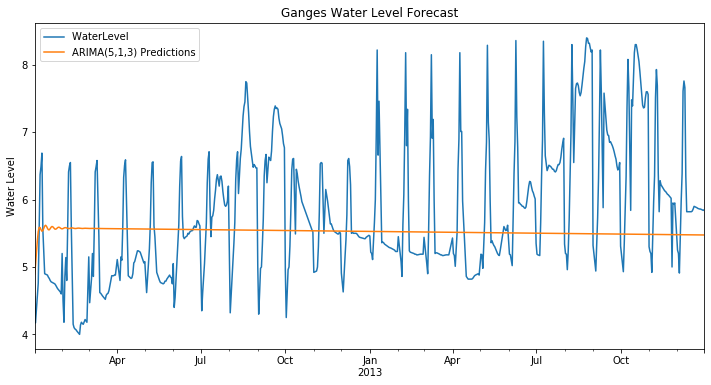

In [24]:
# Plot predictions against known values
title = 'Ganges Water Level Forecast'
ylabel='Water Level'
xlabel='' # we don't really need a label here

ax = test['WaterLevel '].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
#ax.yaxis.set_major_formatter(formatter);

### Evaluate the Model

In [19]:
from sklearn.metrics import mean_squared_error

error = mean_squared_error(test['WaterLevel '], predictions)
print(f'ARIMA(5,1,3) MSE Error: {error:11.10}')

ARIMA(5,1,3) MSE Error: 1.025692311


In [20]:
from statsmodels.tools.eval_measures import rmse

error = rmse(test['WaterLevel '], predictions)
print(f'ARIMA(5,1,3) RMSE Error: {error:11.10}')

ARIMA(5,1,3) RMSE Error: 1.012764687


### Retrain the model on the full data, and forecast the future

In [21]:
model = ARIMA(df['WaterLevel '],order=(5,1,3))
results = model.fit()
fcast = results.predict(len(df),len(df)+11,typ='levels').rename('ARIMA(5,1,3) Forecast')

[Text(0, 0.5, 'Chained 2012 Dollars'), Text(0.5, 0, '')]

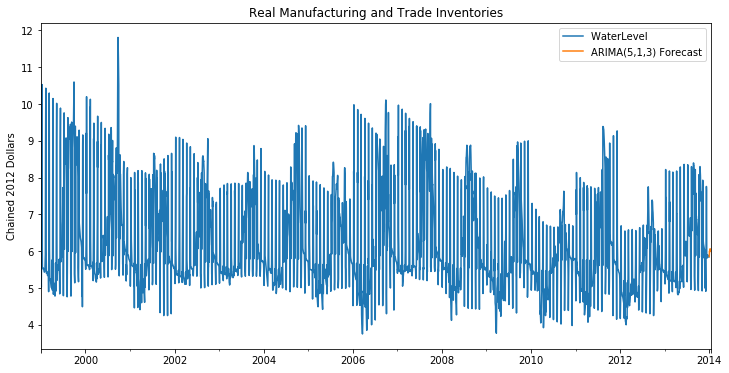

In [23]:
# Plot predictions against known values
title = 'Real Manufacturing and Trade Inventories'
ylabel='Chained 2012 Dollars'
xlabel='' # we don't really need a label here

ax = df['WaterLevel '].plot(legend=True,figsize=(12,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
#ax.yaxis.set_major_formatter(formatter);